# Volatility Analysis

**EDA: Volatility Analysis**

This notebook explores price volatility for the companies currently loaded
into the SmartStock data warehouse: daily return volatility, rolling
standard deviation, and intraday (high-low) trading ranges.

In [1]:
import sys
import warnings
from pathlib import Path

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt


warnings.filterwarnings("ignore", message=".*only supports SQLAlchemy.*")

from src.utils.database import get_connection

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Load Data

In [2]:
with get_connection() as conn:
    companies_df = pd.read_sql(
        "SELECT company_id, symbol, company_name, sector FROM companies ORDER BY symbol;",
        conn,
    )
    prices_df = pd.read_sql(
        """
        SELECT hp.company_id, c.symbol, hp.date, hp.open, hp.high, hp.low, hp.close, hp.volume
        FROM historical_prices hp
        JOIN companies c ON c.company_id = hp.company_id
        ORDER BY c.symbol, hp.date;
        """,
        conn,
    )

prices_df["date"] = pd.to_datetime(prices_df["date"])
print(f"Loaded {len(companies_df)} companies and {len(prices_df)} price rows.")

Loaded 5 companies and 1825 price rows.


## 2. Daily Return Volatility

Standard deviation of daily percentage returns per symbol — the most common
single-number measure of how volatile a stock has been over the loaded date
range. Higher values mean larger day-to-day swings.

In [3]:
if prices_df.empty:
    print("No price data found. Run the ingestion + ETL pipeline first (see the prerequisite note above).")
else:
    returns_df = prices_df.sort_values(["symbol", "date"]).copy()
    returns_df["daily_return_pct"] = returns_df.groupby("symbol")["close"].pct_change() * 100

    volatility_summary = (
        returns_df.groupby("symbol")["daily_return_pct"]
        .agg(["mean", "std", "min", "max"])
        .rename(columns={"mean": "avg_daily_return_pct", "std": "volatility_pct", "min": "worst_day_pct", "max": "best_day_pct"})
        .sort_values("volatility_pct", ascending=False)
    )
    volatility_summary

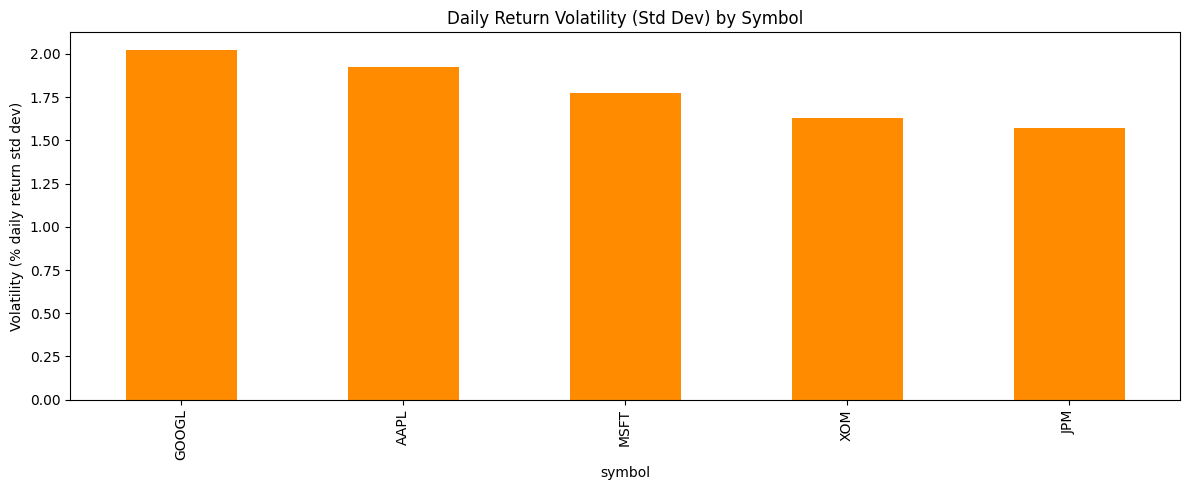

In [4]:
if not prices_df.empty:
    fig, ax = plt.subplots()
    volatility_summary["volatility_pct"].plot(kind="bar", ax=ax, color="darkorange")
    ax.set_title("Daily Return Volatility (Std Dev) by Symbol")
    ax.set_ylabel("Volatility (% daily return std dev)")
    plt.tight_layout()
    plt.show()

## 3. Rolling Volatility (14-Day Window)

A rolling standard deviation shows whether a stock's volatility is currently
rising, falling, or stable, rather than collapsing the whole date range into
one number as in section 2.

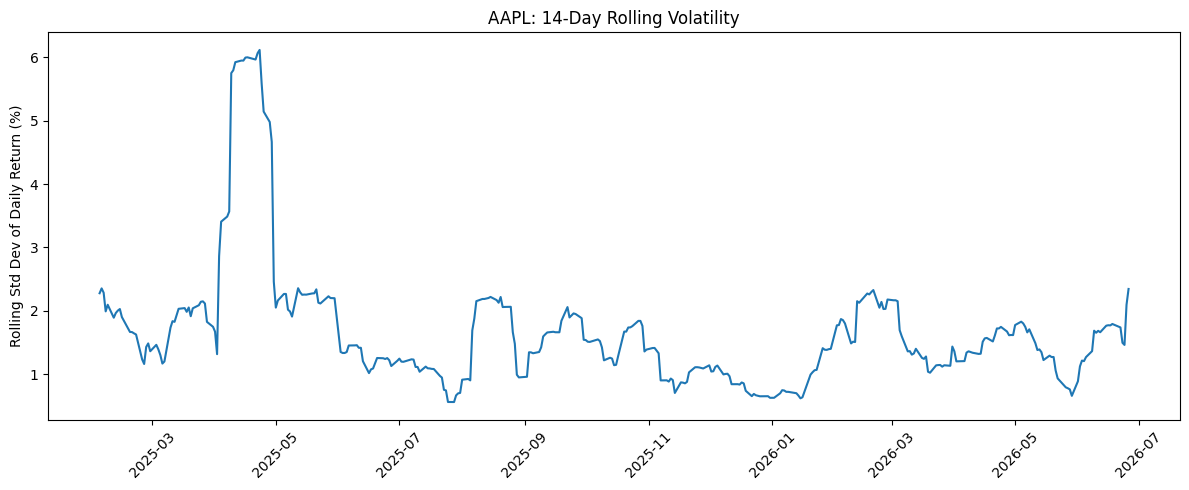

In [5]:
ROLLING_WINDOW = 14

if not prices_df.empty:
    symbols = prices_df["symbol"].unique()
    target_symbol = symbols[0]  # change this to inspect a different symbol

    symbol_returns = returns_df[returns_df["symbol"] == target_symbol].sort_values("date").copy()
    symbol_returns["rolling_volatility_pct"] = (
        symbol_returns["daily_return_pct"].rolling(window=ROLLING_WINDOW).std()
    )

    fig, ax = plt.subplots()
    ax.plot(symbol_returns["date"], symbol_returns["rolling_volatility_pct"])
    ax.set_title(f"{target_symbol}: {ROLLING_WINDOW}-Day Rolling Volatility")
    ax.set_ylabel("Rolling Std Dev of Daily Return (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 4. Intraday Trading Range

The daily high-low spread, as a percentage of the day's open price, is a
second, complementary view of volatility that doesn't depend on
period-over-period returns — it captures how much a stock moved *within*
a single trading day.

In [6]:
if not prices_df.empty:
    range_df = prices_df.copy()
    range_df["intraday_range_pct"] = (range_df["high"] - range_df["low"]) / range_df["open"] * 100

    avg_range_by_symbol = (
        range_df.groupby("symbol")["intraday_range_pct"]
        .mean()
        .rename("avg_intraday_range_pct")
        .sort_values(ascending=False)
    )
    avg_range_by_symbol

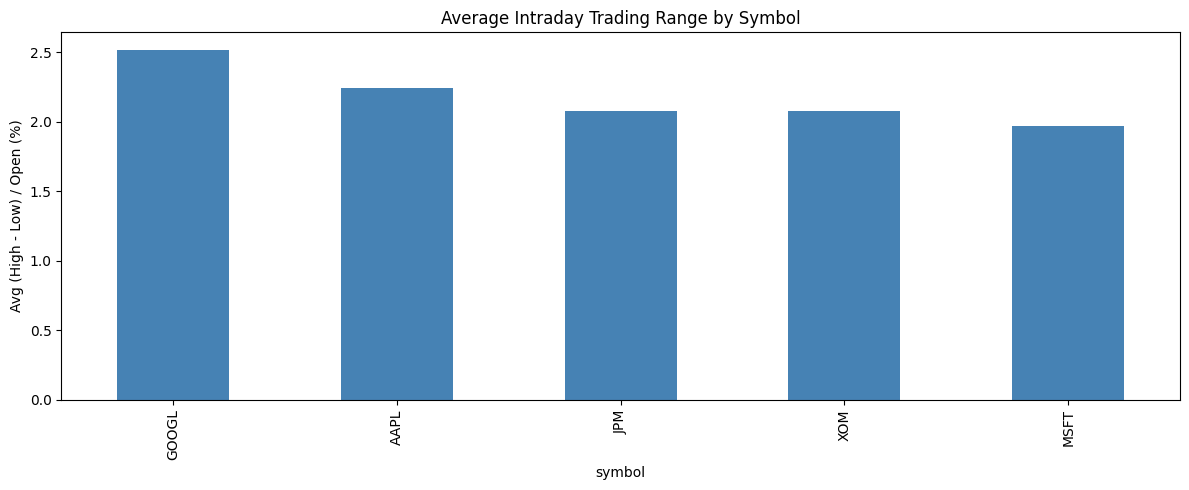

In [7]:
if not prices_df.empty:
    fig, ax = plt.subplots()
    avg_range_by_symbol.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title("Average Intraday Trading Range by Symbol")
    ax.set_ylabel("Avg (High - Low) / Open (%)")
    plt.tight_layout()
    plt.show()